<a href="https://colab.research.google.com/github/Mihailo-Obradovic28/cybersecurity-neural-networks/blob/main/cyber_projekat_dos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np

df = pd.read_parquet('/content/drive/MyDrive/cyber_projekat/data/DoS-Wednesday-no-metadata.parquet')
print(df.shape)
print(df.head())

(584991, 78)
   Protocol  Flow Duration  Total Fwd Packets  Total Backward Packets  \
0         6          38308                  1                       1   
1         6            479                 11                       5   
2         6           1095                 10                       6   
3         6          15206                 17                      12   
4         6           1092                  9                       6   

   Fwd Packets Length Total  Bwd Packets Length Total  Fwd Packet Length Max  \
0                         6                         6                      6   
1                       172                       326                     79   
2                      3150                      3150                   1575   
3                      3452                      6660                   1313   
4                      3150                      3152                   1575   

   Fwd Packet Length Min  Fwd Packet Length Mean  Fwd Packet Length

In [3]:
print(df.columns.tolist())

['Protocol', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Fwd Packets Length Total', 'Bwd Packets Length Total', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Packet Length Min', 'Packet Length Max', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count', 'Down/Up Ra

In [4]:
print(df.dtypes)
print(df.isnull().sum())

Protocol                        int8
Flow Duration                  int32
Total Fwd Packets              int32
Total Backward Packets         int32
Fwd Packets Length Total       int32
                              ...   
Idle Mean                    float32
Idle Std                     float32
Idle Max                       int32
Idle Min                       int32
Label                       category
Length: 78, dtype: object
Protocol                    0
Flow Duration               0
Total Fwd Packets           0
Total Backward Packets      0
Fwd Packets Length Total    0
                           ..
Idle Mean                   0
Idle Std                    0
Idle Max                    0
Idle Min                    0
Label                       0
Length: 78, dtype: int64


In [5]:
print(df['Label'].value_counts())

Label
Benign              391235
DoS Hulk            172846
DoS GoldenEye        10286
DoS slowloris         5385
DoS Slowhttptest      5228
Heartbleed              11
Name: count, dtype: int64


In [6]:
df['Label'] = df['Label'].apply(lambda x: 0 if x == 'Benign' else 1)
print(df['Label'].value_counts())

Label
0    391235
1    193756
Name: count, dtype: int64


In [7]:
X = df.drop(columns=['Label'])
y = df['Label']
print(X.shape)
print(y.value_counts())

(584991, 77)
Label
0    391235
1    193756
Name: count, dtype: int64


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
#normalizacija
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(X_train.shape)
print(X_test.shape)

(467992, 77)
(116999, 77)


In [9]:
#resavanje neravnoteze
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_sm,y_train_sm = smote.fit_resample(X_train,y_train)
print(y_train_sm.value_counts())

Label
0    313029
1    313029
Name: count, dtype: int64


In [10]:
import tensorflow as tf
from tensorflow import keras

model = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(X_train_sm.shape[1],)),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         9,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,353 (79.50 KB)

 Trainable params: 20,353 (79.50 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
history = model.fit(
    X_train_sm, y_train_sm,
    epochs=10,
    batch_size=512,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
979/979 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - accuracy: 0.9729 - loss: 0.0650 - val_accuracy: 0.9726 - val_loss: 0.0568
Epoch 2/10
979/979 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.9837 - loss: 0.0361 - val_accuracy: 0.9942 - val_loss: 0.0314
Epoch 3/10
979/979 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9857 - loss: 0.0319 - val_accuracy: 0.9941 - val_loss: 0.0326
Epoch 4/10
979/979 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9869 - loss: 0.0299 - val_accuracy: 0.9941 - val_loss: 0.0229
Epoch 5/10
979/979 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.9871 - loss: 0.0293 - val_accuracy: 0.9870 - val_loss: 0.0378
Epoch 6/10
979/979 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9879 - loss: 0.0275 - val_accuracy: 0.9957 - val_loss: 0.0219
Epoch 7/10
979/979 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9882 - loss: 0.0270 - val_accuracy: 0.9959 - val_loss: 0.0213
Epoch 8/10
979/979 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9892 - loss: 0.0260 - val_accuracy

3657/3657 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step
              precision    recall  f1-score   support

      Benign       1.00      0.98      0.99     78206
       Napad       0.97      1.00      0.98     38793

    accuracy                           0.99    116999
   macro avg       0.98      0.99      0.99    116999
weighted avg       0.99      0.99      0.99    116999



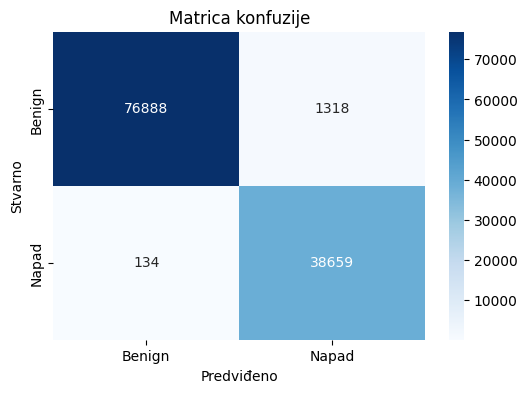

In [12]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Predikcije
y_pred = (model.predict(X_test) > 0.5).astype(int)

# Classification report
print(classification_report(y_test, y_pred, target_names=['Benign', 'Napad']))


cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Napad'],
            yticklabels=['Benign', 'Napad'])
plt.title('Matrica konfuzije')
plt.ylabel('Stvarno')
plt.xlabel('Predviđeno')
plt.show()

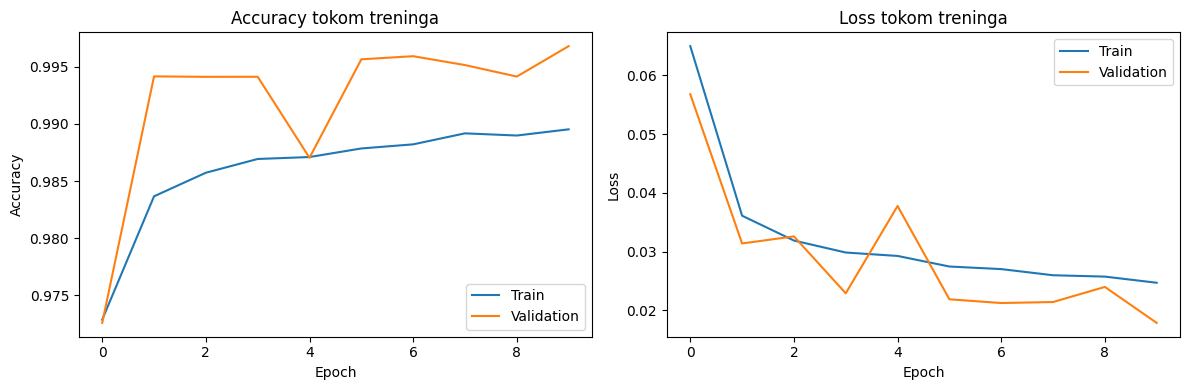

In [13]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy tokom treninga')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss tokom treninga')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()